In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.colors import COLORS

In [12]:
param_search_2d_ddpm_adc_large_group = pd.read_csv("experiment_2/exp_2_2_fixed/dice_scores_param_search_soop_large_group.csv")
param_search_2d_ddpm_adc_medium_group = pd.read_csv("experiment_2/exp_2_2_fixed/dice_scores_param_search_soop_medium_group.csv")
param_search_2d_ddpm_adc_small_group = pd.read_csv("experiment_2/exp_2_2_fixed/dice_scores_param_search_soop_small_group.csv")

/tmp/ipykernel_2139225/4234041751.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_2139225/4234041751.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


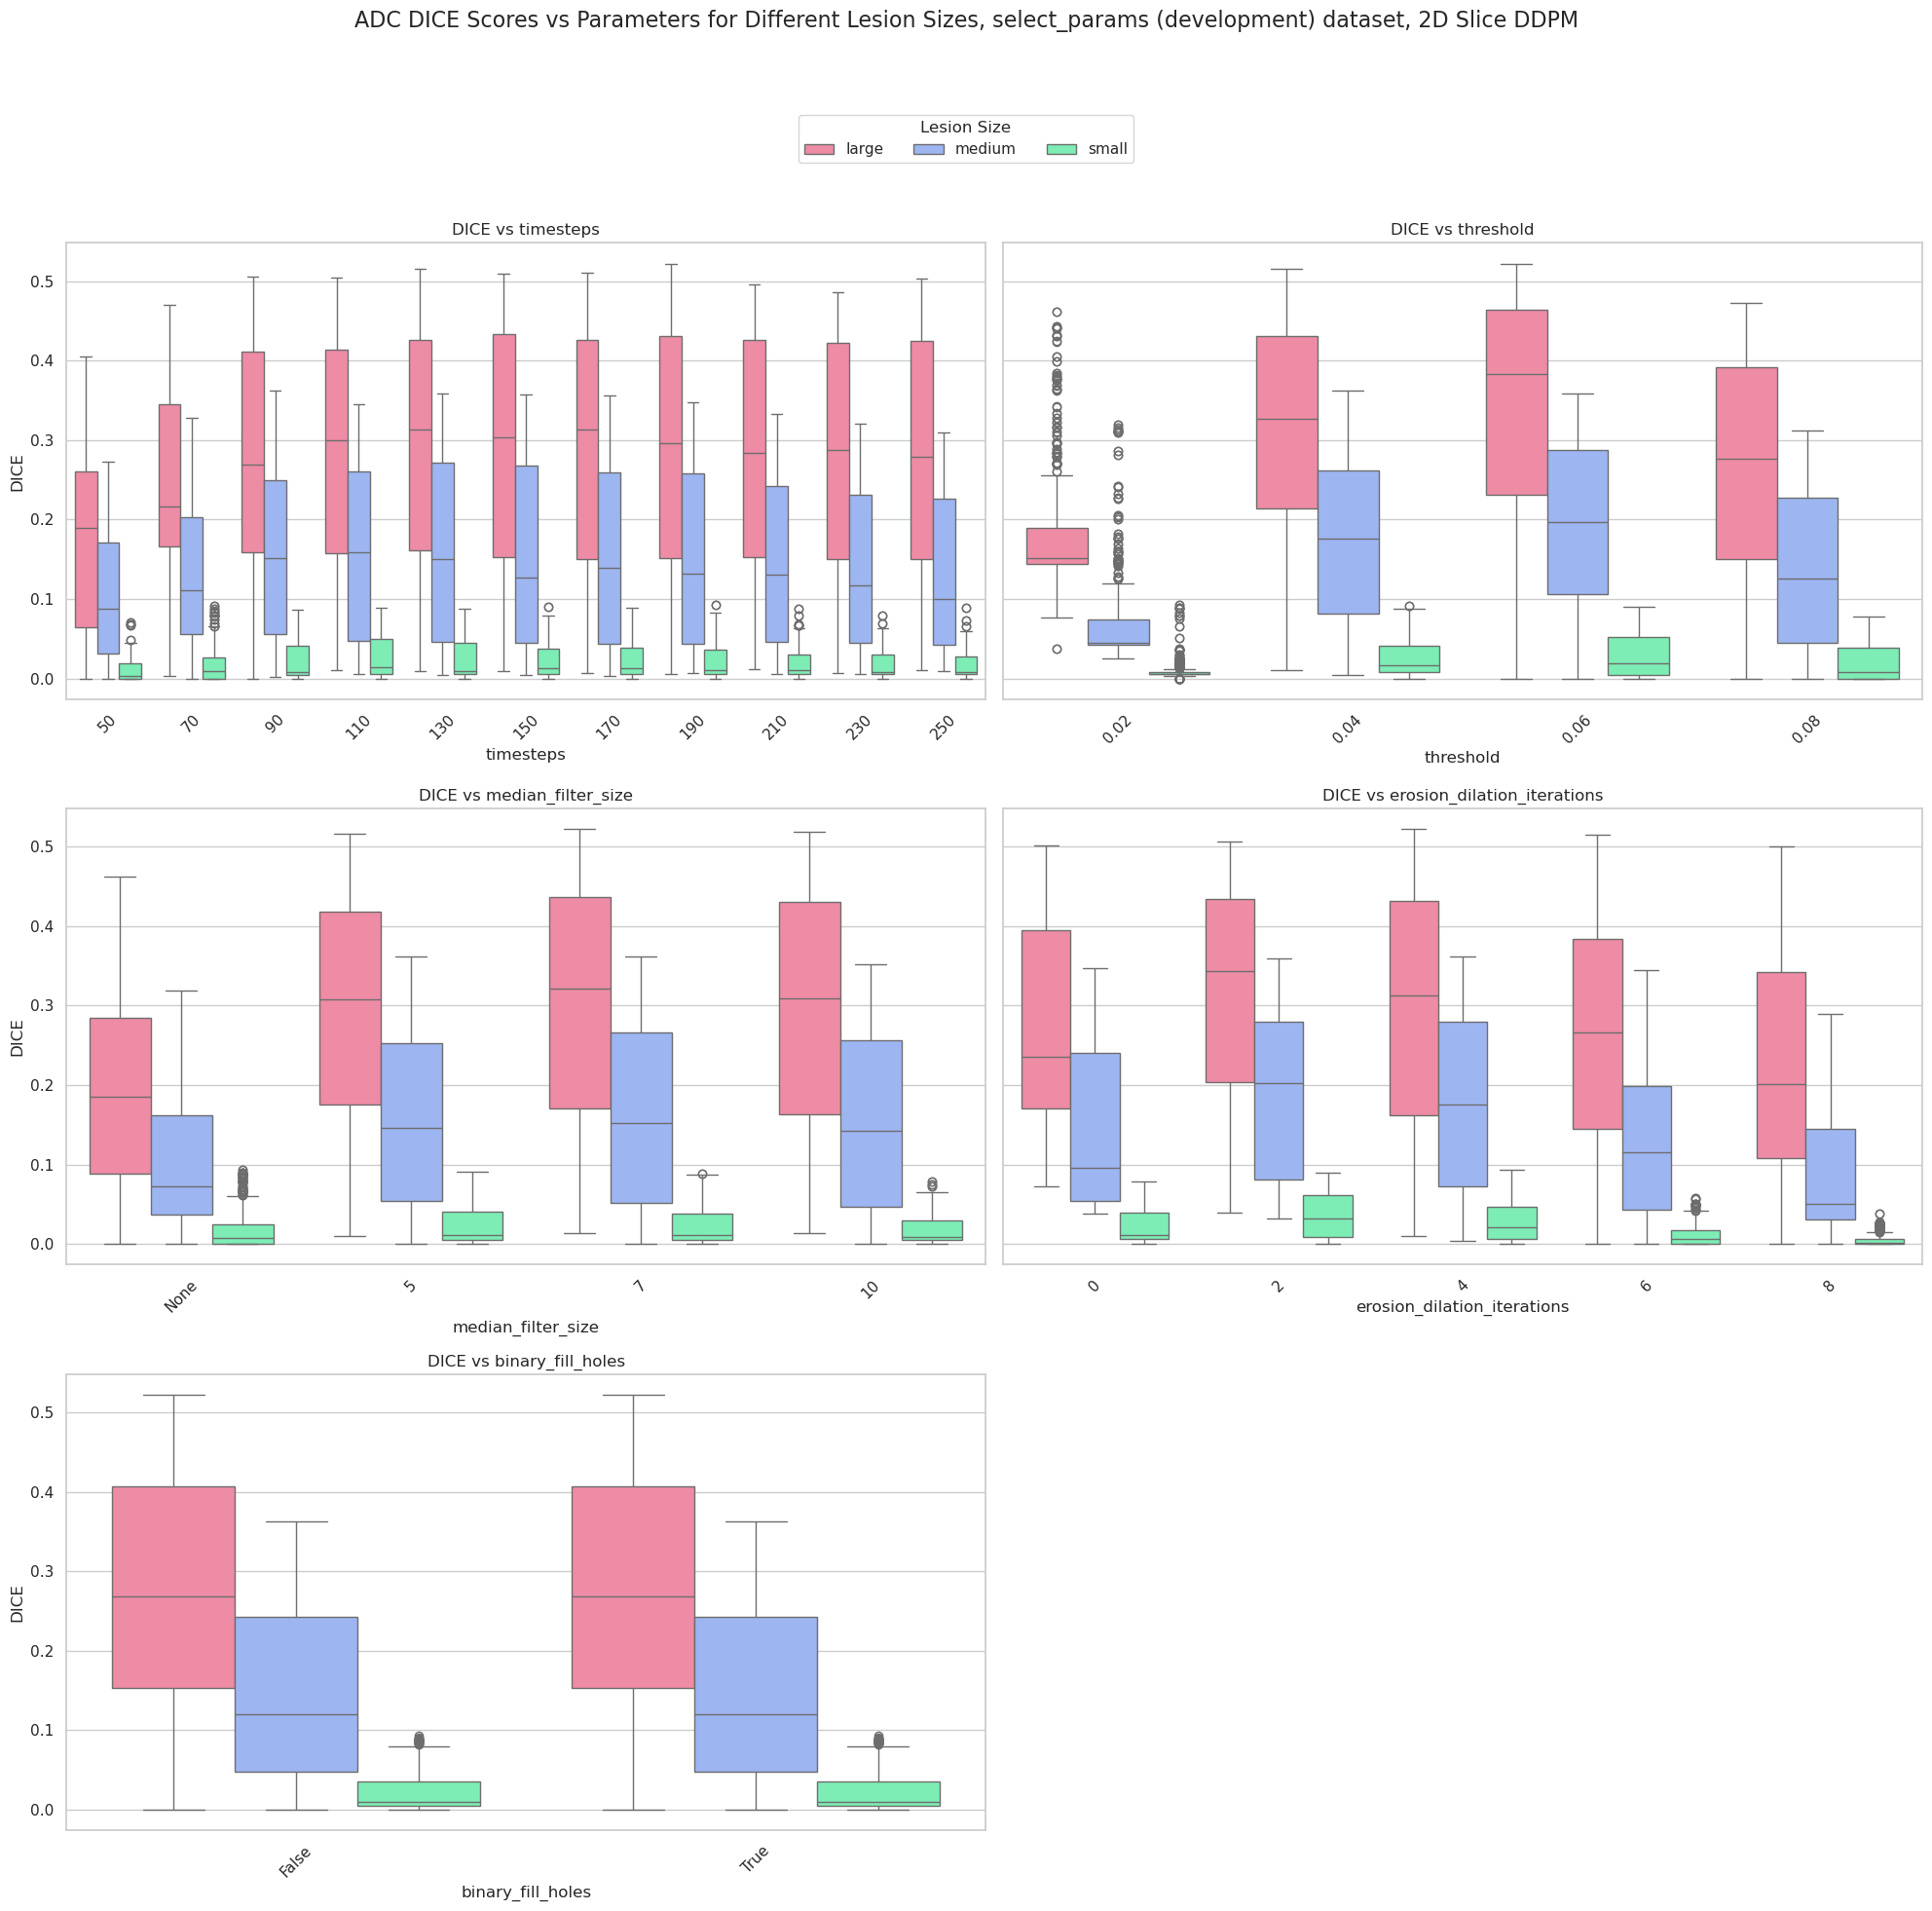

In [21]:
# Combine the three dataframes into one for grouped plotting
plot_df = pd.concat(
    [
        param_search_2d_ddpm_adc_large_group.assign(group="large"),
        param_search_2d_ddpm_adc_medium_group.assign(group="medium"),
        param_search_2d_ddpm_adc_small_group.assign(group="small"),
    ],
    ignore_index=True,
)

params = [
    "timesteps",
    "threshold",
    "median_filter_size",
    "erosion_dilation_iterations",
    "binary_fill_holes",
]

orders = {p: sorted(plot_df[p].unique()) for p in params}
group_palette = {
    "large": COLORS.MEDIUM_RED,
    "medium": COLORS.MEDIUM_BLUE,
    "small": COLORS.MEDIUM_GREEN,
}

fig, axes = plt.subplots(3, 2, figsize=(20, 20), sharey=True)
axes = axes.flatten()

for i, param in enumerate(params):
    ax = axes[i]
    sns.boxplot(
        data=plot_df,
        x=param,
        y="DICE",
        hue="group",
        hue_order=["large", "medium", "small"],
        order=orders[param],
        ax=ax,
        palette=group_palette,
    )
    ax.set_title(f"DICE vs {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("DICE")
    ax.tick_params(axis="x", rotation=45)
    if param == "median_filter_size":
        ax.set_xticklabels(
            ["None" if t.get_text() == "-1" else t.get_text() for t in ax.get_xticklabels()],
            rotation=45,
        )
    elif param=="binary_fill_holes":
        ax.set_xticklabels(
            ["False" if t.get_text() == "0" else "True" for t in ax.get_xticklabels()],
            rotation=45,
        )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

axes[-1].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
plt.suptitle(
    "ADC DICE Scores vs Parameters for Different Lesion Sizes, select_params (development) dataset, 2D Slice DDPM",
    fontsize=16,
    y=0.98,
)
fig.legend(
    handles,
    labels,
    title="Lesion Size",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=3,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()